# Introduction & Dataset Setup


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

print("Libraries imported successfully!")

Libraries imported successfully!


# Load Sample Dataset: House Prices with Realistic Issues

In [72]:
df=pd.read_csv("housing 2.csv")

# EDA

In [73]:
df.shape

(21613, 21)

In [74]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.000,2,1.000,1180,5650,1.000,0,0,3,7,1180,0,1955,0,98178,47.511,-122.257,1340,5650
1,6414100192,20141209T000000,538000.000,3,2.250,2570,7242,2.000,0,0,3,7,2170,400,1951,1991,98125,47.721,-122.319,1690,7639
2,5631500400,20150225T000000,180000.000,2,1.000,770,10000,1.000,0,0,3,6,770,0,1933,0,98028,47.738,-122.233,2720,8062
3,2487200875,20141209T000000,604000.000,4,3.000,1960,5000,1.000,0,0,5,7,1050,910,1965,0,98136,47.521,-122.393,1360,5000
4,1954400510,20150218T000000,510000.000,3,2.000,1680,8080,1.000,0,0,3,8,1680,0,1987,0,98074,47.617,-122.045,1800,7503


In [75]:
print("Data types:")
dtype_summary = pd.DataFrame({
        'Column': df.columns,
        'Type': df.dtypes,
        'Non-Null Count': df.notnull().sum(),
        'Null Count': df.isnull().sum()
    })
display(dtype_summary)

Data types:


,Column,Type,Non-Null Count,Null Count
id,id,int64,21613,0
date,date,object,21613,0
price,price,float64,21613,0
bedrooms,bedrooms,int64,21613,0
bathrooms,bathrooms,float64,21613,0
sqft_living,sqft_living,int64,21613,0
sqft_lot,sqft_lot,int64,21613,0
floors,floors,float64,21613,0
waterfront,waterfront,int64,21613,0
view,view,int64,21613,0


In [76]:
print("\nCount by data type:")
dtype_counts = df.dtypes.value_counts()
display(dtype_counts)


Count by data type:


int64      15
float64     5
object      1
Name: count, dtype: int64

In [ ]:
# we verify the missing values beause missing values can affect the analysis and machine learning models
    
# Missing values summary
missing_total = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
    
missing_df = pd.DataFrame({
        'Missing Values': missing_total,
        'Percentage (%)': missing_percent.round(2)
    })
display(missing_df)


⚠️ 3. MISSING VALUES ANALYSIS
----------------------------------------


,Missing Values,Percentage (%)
id,0,0.000
date,0,0.000
price,0,0.000
bedrooms,0,0.000
bathrooms,0,0.000
sqft_living,0,0.000
sqft_lot,0,0.000
floors,0,0.000
waterfront,0,0.000
view,0,0.000




In [105]:
# Create figure and axis
fig, ax1 = plt.subplots(figsize=(14, 5))  # Use plt.subplots() instead of plt.figure()
        
# Bar plot
bars = ax1.barh(missing_df.index[:20], missing_df['Percentage (%)'][:20])
ax1.set_xlabel('Missing Values (%)')
ax1.set_title('Top Columns with Missing Values')
ax1.invert_yaxis()
        
# Add value labels
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 1, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%', ha='left', va='center')

plt.tight_layout()
plt.show()

In [ ]:
# checking for duplicates to take them in consideration for cleaning because duplicates affect the analysis and can lead to incorrect results. 
duplicate_rows = df.duplicated().sum()
    
if duplicate_rows > 0:
    print(f"Found {duplicate_rows} exact duplicate rows ({duplicate_rows/len(df)*100:.2f}%)")
    display(df[df.duplicated()].head())
else:
    print("✅ No exact duplicates found")
    
    # Check for near duplicates based on key columns
key_columns = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'zipcode']
available_keys = [col for col in key_columns if col in df.columns]
    
if available_keys:
    near_duplicates = df.duplicated(subset=available_keys, keep=False).sum()
        
if near_duplicates > 0:
    print(f"\nFound {near_duplicates} near-duplicate rows based on key columns: {available_keys}")
    # Show groups of duplicates
    duplicate_groups = df[df.duplicated(subset=available_keys, keep=False)]
    grouped = duplicate_groups.groupby(available_keys).size().reset_index(name='count')
    display(grouped[grouped['count'] > 1].sort_values('count', ascending=False).head())
    

✅ No exact duplicates found

Found 132 near-duplicate rows based on key columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'zipcode']


,price,bedrooms,bathrooms,sqft_living,zipcode,count
59,629950.000,3,2.500,1680,98119,3
46,510000.000,6,4.500,3300,98052,3
0,125000.000,3,1.000,920,98002,2
48,539950.000,3,2.500,1330,98117,2
35,424950.000,5,3.500,2760,98056,2


In [ ]:
#it helps to know the type of data in the columns if ordinal or nominal
#1. Nominal Data
#Definition: Categories with no inherent order.
#Examples:
#Gender (Male, Female, Non-binary)
#Country of origin (Tunisia, France, Japan)
#Colors (Red, Blue, Green)
#Key point: You can label or group, but not rank them.
#2. Ordinal Data
#Definition: Categories with a meaningful order, but no consistent spacing between levels.
#Examples:
#Education level (High School < Bachelor’s < Master’s < PhD)
#Customer satisfaction (Very Dissatisfied < Dissatisfied < Neutral < Satisfied < Very Satisfied)
#Likert scale responses
#Key point: Order matters, but differences between values aren’t quantifiable (e.g., the gap between "Satisfied" and "Very Satisfied" isn’t necessarily the same as between "Neutral" and "Satisfied").
unique_counts = {}
for col in df.columns:
        unique_vals = df[col].nunique()
        unique_counts[col] = unique_vals
        
        if unique_vals <= 10:
            print(f"\n{col}: {unique_vals} unique values")
            if pd.api.types.is_numeric_dtype(df[col]):
                value_counts = df[col].value_counts().sort_index()
            else:
                value_counts = df[col].value_counts()
            display(value_counts)


floors: 6 unique values


floors
1.000    10680
1.500     1910
2.000     8241
2.500      161
3.000      613
3.500        8
Name: count, dtype: int64


waterfront: 2 unique values


waterfront
0    21450
1      163
Name: count, dtype: int64


view: 5 unique values


view
0    19489
1      332
2      963
3      510
4      319
Name: count, dtype: int64


condition: 5 unique values


condition
1       30
2      172
3    14031
4     5679
5     1701
Name: count, dtype: int64

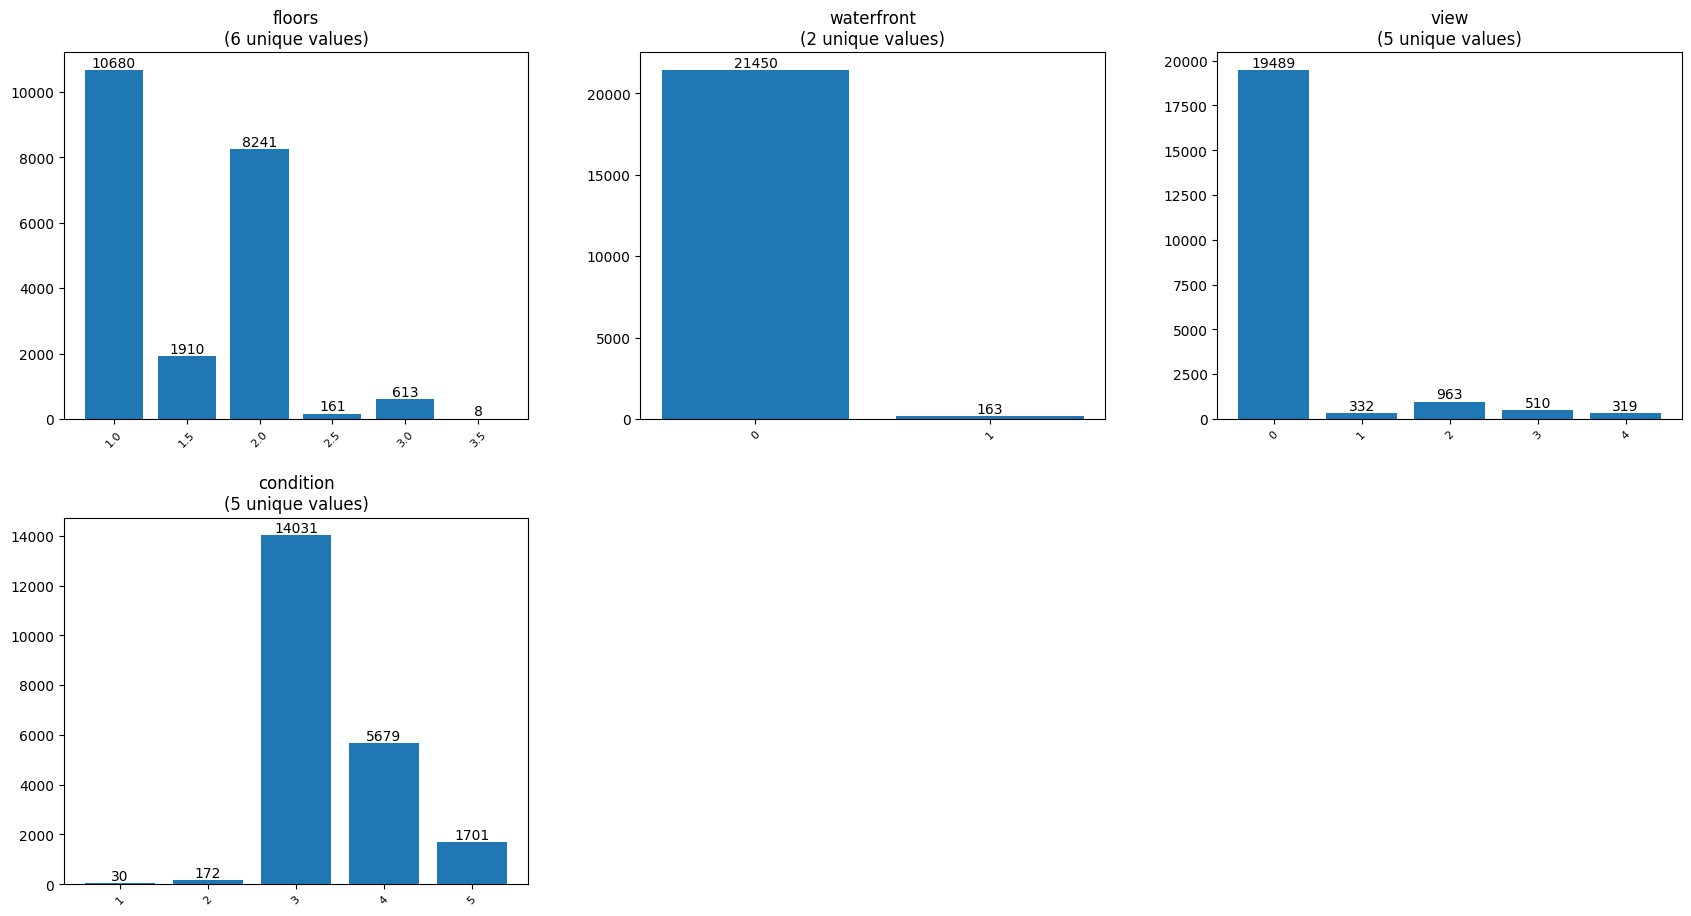

In [81]:
# Get columns with 10 or fewer unique values
categorical_cols = [col for col in df.columns if df[col].nunique() <= 10]

# Calculate number of rows and columns for subplots
n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.tight_layout(pad=5.0)

# Flatten axes for easy iteration
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    # Get value counts
    if pd.api.types.is_numeric_dtype(df[col]):
        value_counts = df[col].value_counts().sort_index()
    else:
        value_counts = df[col].value_counts()
    
    # Create bar plot
    bars = axes[i].bar(value_counts.index.astype(str), value_counts.values)
    axes[i].set_title(f'{col}\n({len(value_counts)} unique values)')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom')

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.show()

In [ ]:
# numerical columns
#1. Continuous (or Real-Valued) Numerical Data
#Definition: Can take any value within a range, including decimals/fractions.
# Infinite possible values between any two points.
# Used for measurements.
# ✅ Examples:
#Height: 172.5 cm
#Temperature: 23.7°C
#Price: $49.99
#Time spent on a website: 12.34 seconds
#📌 Subtypes:
#Interval: No true zero (e.g., temperature in °C or °F).
#Ratio: Has a meaningful zero (e.g., weight, time, income).
#2. Discrete Numerical Data
#Definition: Represents countable values—usually integers.
#Finite or countably infinite set of possible values.
#Often answers “how many?”
#✅ Examples:
#Number of customers: 150
#Items sold: 23
#Children in a family: 2
#Failed login attempts: 3
numerical_cols = df.select_dtypes(include=[np.number]).columns
    
df[numerical_cols].describe().T 
        



,count,mean,std,min,25%,50%,75%,max
id,21613.000,4580306147.710,2876569751.889,1000102.000,2123049194.000,3904930410.000,7308900445.000,9900000190.000
price,21613.000,540088.577,367126.825,75000.000,321950.000,450000.000,645000.000,7700000.000
bedrooms,21613.000,3.371,0.930,0.000,3.000,3.000,4.000,33.000
bathrooms,21613.000,2.115,0.770,0.000,1.750,2.250,2.500,8.000
sqft_living,21613.000,2079.900,918.441,290.000,1427.000,1910.000,2550.000,13540.000
sqft_lot,21613.000,15106.968,41420.512,520.000,5040.000,7618.000,10688.000,1651359.000
floors,21613.000,1.494,0.540,1.000,1.000,1.500,2.000,3.500
waterfront,21613.000,0.008,0.087,0.000,0.000,0.000,0.000,1.000
view,21613.000,0.234,0.766,0.000,0.000,0.000,0.000,4.000
condition,21613.000,3.409,0.651,1.000,3.000,3.000,4.000,5.000


In [83]:
# Categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    
if len(categorical_cols) > 0:
        print("\nCategorical columns summary:")
        cat_summary = pd.DataFrame({
            'Column': categorical_cols,
            'Unique Values': [df[col].nunique() for col in categorical_cols],
            'Most Common': [df[col].mode()[0] if not df[col].mode().empty else np.nan 
                           for col in categorical_cols],
            'Frequency of Most Common': [df[col].value_counts().iloc[0] 
                                        if not df[col].value_counts().empty else 0 
                                        for col in categorical_cols]
        })
        display(cat_summary)


Categorical columns summary:


,Column,Unique Values,Most Common,Frequency of Most Common
0,date,372,20140623T000000,142


Outliers detected (using IQR method):


,outlier_count,percentage,min,max,lower_bound,upper_bound
price,1146.000,5.300,75000.000,7700000.000,-162625.000,1129575.000
bedrooms,546.000,2.530,0.000,33.000,1.500,5.500
bathrooms,571.000,2.640,0.000,8.000,0.625,3.625
sqft_living,572.000,2.650,290.000,13540.000,-257.500,4234.500
sqft_lot,2425.000,11.220,520.000,1651359.000,-3432.000,19160.000
waterfront,163.000,0.750,0.000,1.000,0.000,0.000
view,2124.000,9.830,0.000,4.000,0.000,0.000
condition,30.000,0.140,1.000,5.000,1.500,5.500
grade,1911.000,8.840,1.000,13.000,5.500,9.500
sqft_above,611.000,2.830,290.000,9410.000,-340.000,3740.000


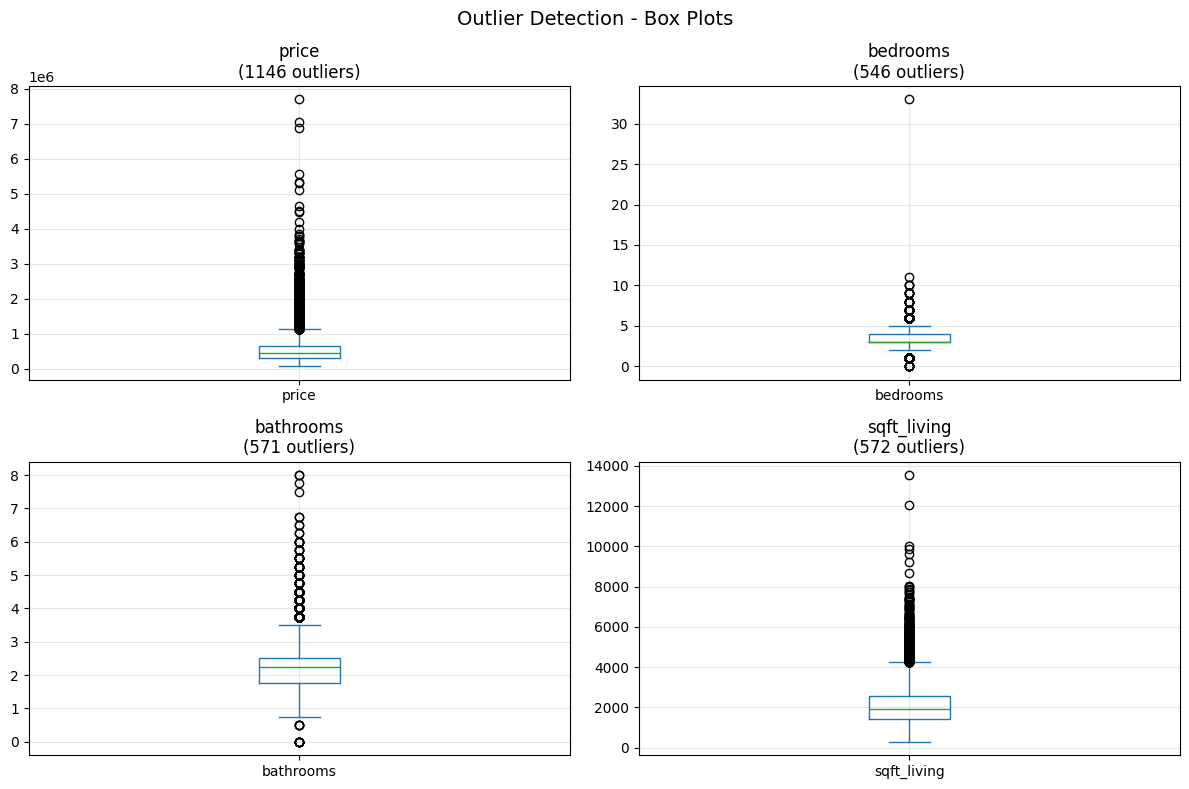

In [ ]:
#OUTLIER DETECTION :outliers can affect the results of many statistical analyses, including regression, ANOVA, and t-tests. 
outliers_summary = {}
    
if len(numerical_cols) > 0:
    for col in numerical_cols:
            # Skip if all values are NaN
            if df[col].notna().sum() == 0:
                continue
                
            # Calculate IQR
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            
            # Define bounds
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Count outliers
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
            outlier_count = outliers.count()
            
            if outlier_count > 0:
                outliers_summary[col] = {
                    'outlier_count': outlier_count,
                    'percentage': (outlier_count / len(df) * 100),
                    'min': df[col].min(),
                    'max': df[col].max(),
                    'lower_bound': lower_bound,
                    'upper_bound': upper_bound
                }
        
    if outliers_summary:
            print("Outliers detected (using IQR method):")
            outliers_df = pd.DataFrame(outliers_summary).T
            outliers_df['percentage'] = outliers_df['percentage'].round(2)
            display(outliers_df)
            
            # Visualize outliers for top columns
            top_outlier_cols = list(outliers_summary.keys())[:4]
            if top_outlier_cols:
                fig, axes = plt.subplots(2, 2, figsize=(12, 8))
                axes = axes.flatten()
                
                for idx, col in enumerate(top_outlier_cols[:4]):
                    ax = axes[idx]
                    df[col].plot(kind='box', ax=ax)
                    ax.set_title(f'{col}\n({outliers_summary[col]["outlier_count"]} outliers)')
                    ax.grid(True, alpha=0.3)
                
                plt.suptitle('Outlier Detection - Box Plots', fontsize=14)
                plt.tight_layout()
                plt.show()
    else:
            print("✅ No outliers detected using IQR method")
    

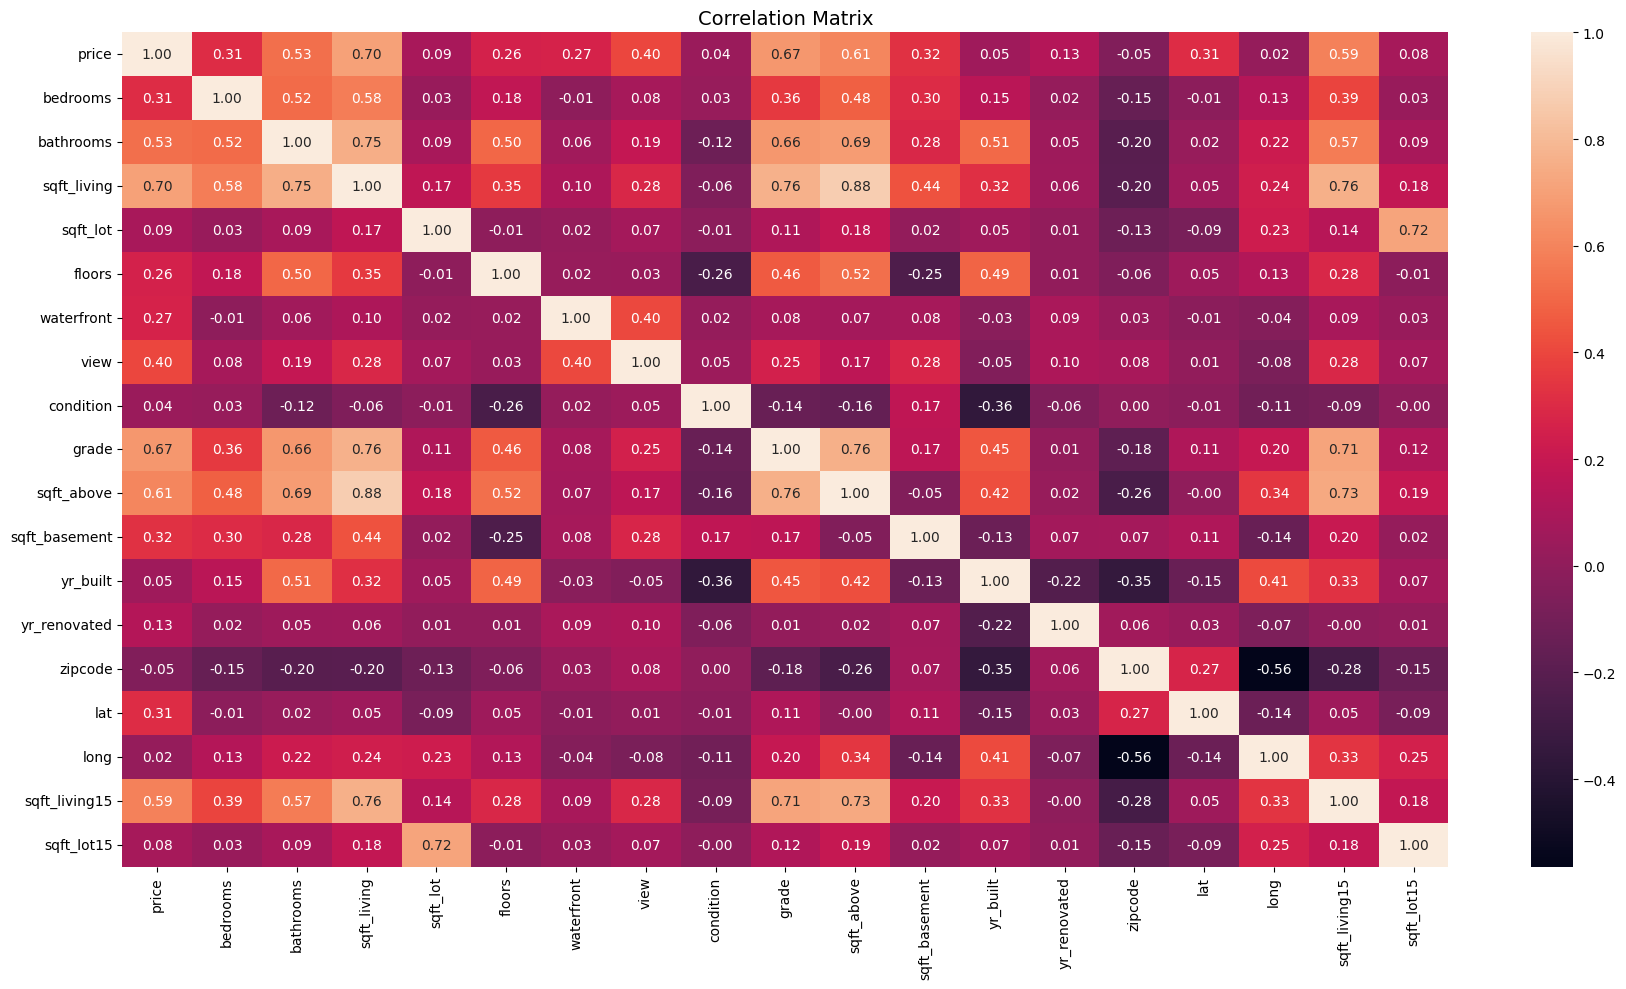

In [ ]:
#correlation matrix: it helps us to understand the relationship between the variables for further featuring engineering 
new_df = df.copy()
df_without_id = new_df.drop('id', axis=1)
num_cols = df_without_id.select_dtypes(include=[np.number]).columns

correlation_matrix = df_without_id[num_cols].corr()
plt.figure(figsize=(18, 10))
sns.heatmap(correlation_matrix,annot=True, fmt='.2f' 
                   )
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Find high correlations :we detect strong correlations to select variables to remove or to create with low correlation linear equations
high_correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_correlations.append({
                'Variable 1': correlation_matrix.columns[i],
                'Variable 2': correlation_matrix.columns[j],
                        'Correlation': correlation_matrix.iloc[i, j]
                    })
        
    if high_correlations:
            print("\nStrong correlations (|r| > 0.7):")
            high_corr_df = pd.DataFrame(high_correlations)
            display(high_corr_df.sort_values('Correlation', key=abs, ascending=False))

    


Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
1,bathrooms,sqft_living,0.755
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
3,sqft_living,sqft_above,0.877
2,sqft_living,grade,0.763
4,sqft_living,sqft_living15,0.756
1,bathrooms,sqft_living,0.755
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
3,sqft_living,sqft_above,0.877
2,sqft_living,grade,0.763
4,sqft_living,sqft_living15,0.756
1,bathrooms,sqft_living,0.755
5,sqft_lot,sqft_lot15,0.719
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
3,sqft_living,sqft_above,0.877
2,sqft_living,grade,0.763
4,sqft_living,sqft_living15,0.756
1,bathrooms,sqft_living,0.755
5,sqft_lot,sqft_lot15,0.719
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
3,sqft_living,sqft_above,0.877
2,sqft_living,grade,0.763
4,sqft_living,sqft_living15,0.756
1,bathrooms,sqft_living,0.755
5,sqft_lot,sqft_lot15,0.719
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
3,sqft_living,sqft_above,0.877
2,sqft_living,grade,0.763
4,sqft_living,sqft_living15,0.756
1,bathrooms,sqft_living,0.755
5,sqft_lot,sqft_lot15,0.719
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
3,sqft_living,sqft_above,0.877
2,sqft_living,grade,0.763
4,sqft_living,sqft_living15,0.756
1,bathrooms,sqft_living,0.755
5,sqft_lot,sqft_lot15,0.719
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
3,sqft_living,sqft_above,0.877
2,sqft_living,grade,0.763
4,sqft_living,sqft_living15,0.756
6,grade,sqft_above,0.756
1,bathrooms,sqft_living,0.755
5,sqft_lot,sqft_lot15,0.719
7,grade,sqft_living15,0.713
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
3,sqft_living,sqft_above,0.877
2,sqft_living,grade,0.763
4,sqft_living,sqft_living15,0.756
6,grade,sqft_above,0.756
1,bathrooms,sqft_living,0.755
8,sqft_above,sqft_living15,0.732
5,sqft_lot,sqft_lot15,0.719
7,grade,sqft_living15,0.713
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
3,sqft_living,sqft_above,0.877
2,sqft_living,grade,0.763
4,sqft_living,sqft_living15,0.756
6,grade,sqft_above,0.756
1,bathrooms,sqft_living,0.755
8,sqft_above,sqft_living15,0.732
5,sqft_lot,sqft_lot15,0.719
7,grade,sqft_living15,0.713
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
3,sqft_living,sqft_above,0.877
2,sqft_living,grade,0.763
4,sqft_living,sqft_living15,0.756
6,grade,sqft_above,0.756
1,bathrooms,sqft_living,0.755
8,sqft_above,sqft_living15,0.732
5,sqft_lot,sqft_lot15,0.719
7,grade,sqft_living15,0.713
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
3,sqft_living,sqft_above,0.877
2,sqft_living,grade,0.763
4,sqft_living,sqft_living15,0.756
6,grade,sqft_above,0.756
1,bathrooms,sqft_living,0.755
8,sqft_above,sqft_living15,0.732
5,sqft_lot,sqft_lot15,0.719
7,grade,sqft_living15,0.713
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
3,sqft_living,sqft_above,0.877
2,sqft_living,grade,0.763
4,sqft_living,sqft_living15,0.756
6,grade,sqft_above,0.756
1,bathrooms,sqft_living,0.755
8,sqft_above,sqft_living15,0.732
5,sqft_lot,sqft_lot15,0.719
7,grade,sqft_living15,0.713
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
3,sqft_living,sqft_above,0.877
2,sqft_living,grade,0.763
4,sqft_living,sqft_living15,0.756
6,grade,sqft_above,0.756
1,bathrooms,sqft_living,0.755
8,sqft_above,sqft_living15,0.732
5,sqft_lot,sqft_lot15,0.719
7,grade,sqft_living15,0.713
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
3,sqft_living,sqft_above,0.877
2,sqft_living,grade,0.763
4,sqft_living,sqft_living15,0.756
6,grade,sqft_above,0.756
1,bathrooms,sqft_living,0.755
8,sqft_above,sqft_living15,0.732
5,sqft_lot,sqft_lot15,0.719
7,grade,sqft_living15,0.713
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
3,sqft_living,sqft_above,0.877
2,sqft_living,grade,0.763
4,sqft_living,sqft_living15,0.756
6,grade,sqft_above,0.756
1,bathrooms,sqft_living,0.755
8,sqft_above,sqft_living15,0.732
5,sqft_lot,sqft_lot15,0.719
7,grade,sqft_living15,0.713
0,price,sqft_living,0.702



Strong correlations (|r| > 0.7):


,Variable 1,Variable 2,Correlation
3,sqft_living,sqft_above,0.877
2,sqft_living,grade,0.763
4,sqft_living,sqft_living15,0.756
6,grade,sqft_above,0.756
1,bathrooms,sqft_living,0.755
8,sqft_above,sqft_living15,0.732
5,sqft_lot,sqft_lot15,0.719
7,grade,sqft_living15,0.713
0,price,sqft_living,0.702


In [96]:
%pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 2.3 MB/s  0:00:09m0:00:0100:01
Note: you may need to restart the kernel to use updated packages.



UNIVARIATE ANALYSIS: TARGET VARIABLE


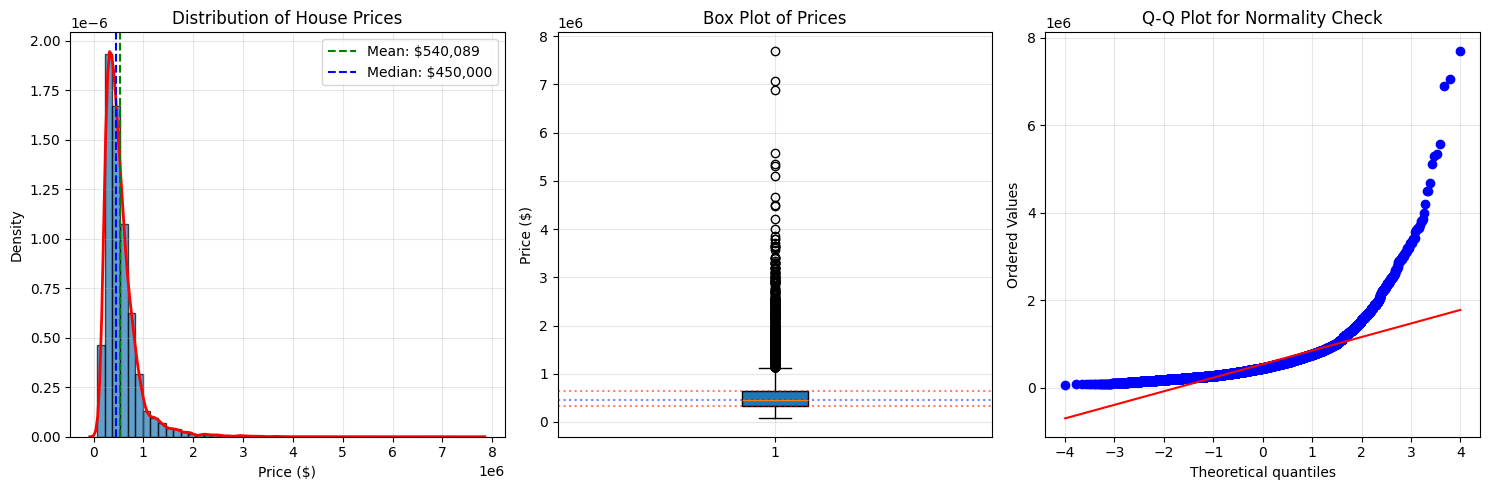


📊 Target Variable Statistics:


,Statistic,Value,Interpretation
0,Mean,"$540,089",Average price
1,Median,"$450,000",Middle value (50th percentile)
2,Std Dev,"$367,127",Spread of prices
3,Min,"$75,000",Cheapest house
4,Max,"$7,700,000",Most expensive house
5,Skewness,4.024,"Right skewed if > 0, left skewed if < 0"
6,Kurtosis,34.586,"Heavy tails if > 0, light tails if < 0"
7,IQR,"$323,050",Middle 50% spread (Q3 - Q1)
8,CV (%),68.0%,Coefficient of Variation (std/mean)



🚨 Outliers detected: 1146 (5.3% of data)
   Lower bound: $-162,625
   Upper bound: $1,129,575


In [ ]:
# Univariate Analysis: Target Variable Distribution
#those plots help us understand the distribution of the target variable
from scipy import stats
print("\n" + "=" * 80)
print("UNIVARIATE ANALYSIS: TARGET VARIABLE")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Histogram with KDE
axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7, density=True)
sns.kdeplot(df['price'], ax=axes[0], color='red', linewidth=2)
axes[0].axvline(df['price'].mean(), color='green', linestyle='--', label=f'Mean: ${df["price"].mean():,.0f}')
axes[0].axvline(df['price'].median(), color='blue', linestyle='--', label=f'Median: ${df["price"].median():,.0f}')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of House Prices')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Box plot
axes[1].boxplot(df['price'], vert=True, patch_artist=True)
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Box Plot of Prices')
axes[1].grid(True, alpha=0.3)

# Calculate and display statistics
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

axes[1].axhline(Q1, color='red', linestyle=':', alpha=0.5, label=f'Q1: ${Q1:,.0f}')
axes[1].axhline(df['price'].median(), color='blue', linestyle=':', alpha=0.5, label=f'Median')
axes[1].axhline(Q3, color='red', linestyle=':', alpha=0.5, label=f'Q3: ${Q3:,.0f}')

# 3. QQ plot for normality check
stats.probplot(df['price'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot for Normality Check')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical summary
print("\n📊 Target Variable Statistics:")
target_stats = pd.DataFrame({
    'Statistic': ['Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Skewness', 'Kurtosis', 'IQR', 'CV (%)'],
    'Value': [
        f"${df['price'].mean():,.0f}",
        f"${df['price'].median():,.0f}",
        f"${df['price'].std():,.0f}",
        f"${df['price'].min():,.0f}",
        f"${df['price'].max():,.0f}",
        f"{df['price'].skew():.3f}",
        f"{df['price'].kurtosis():.3f}",
        f"${IQR:,.0f}",
        f"{(df['price'].std() / df['price'].mean() * 100):.1f}%"
    ],
    'Interpretation': [
        'Average price',
        'Middle value (50th percentile)',
        'Spread of prices',
        'Cheapest house',
        'Most expensive house',
        'Right skewed if > 0, left skewed if < 0',
        'Heavy tails if > 0, light tails if < 0',
        'Middle 50% spread (Q3 - Q1)',
        'Coefficient of Variation (std/mean)'
    ]
})
display(target_stats)

# Check for outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"\n🚨 Outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of data)")
if len(outliers) > 0:
    print(f"   Lower bound: ${lower_bound:,.0f}")
    print(f"   Upper bound: ${upper_bound:,.0f}")

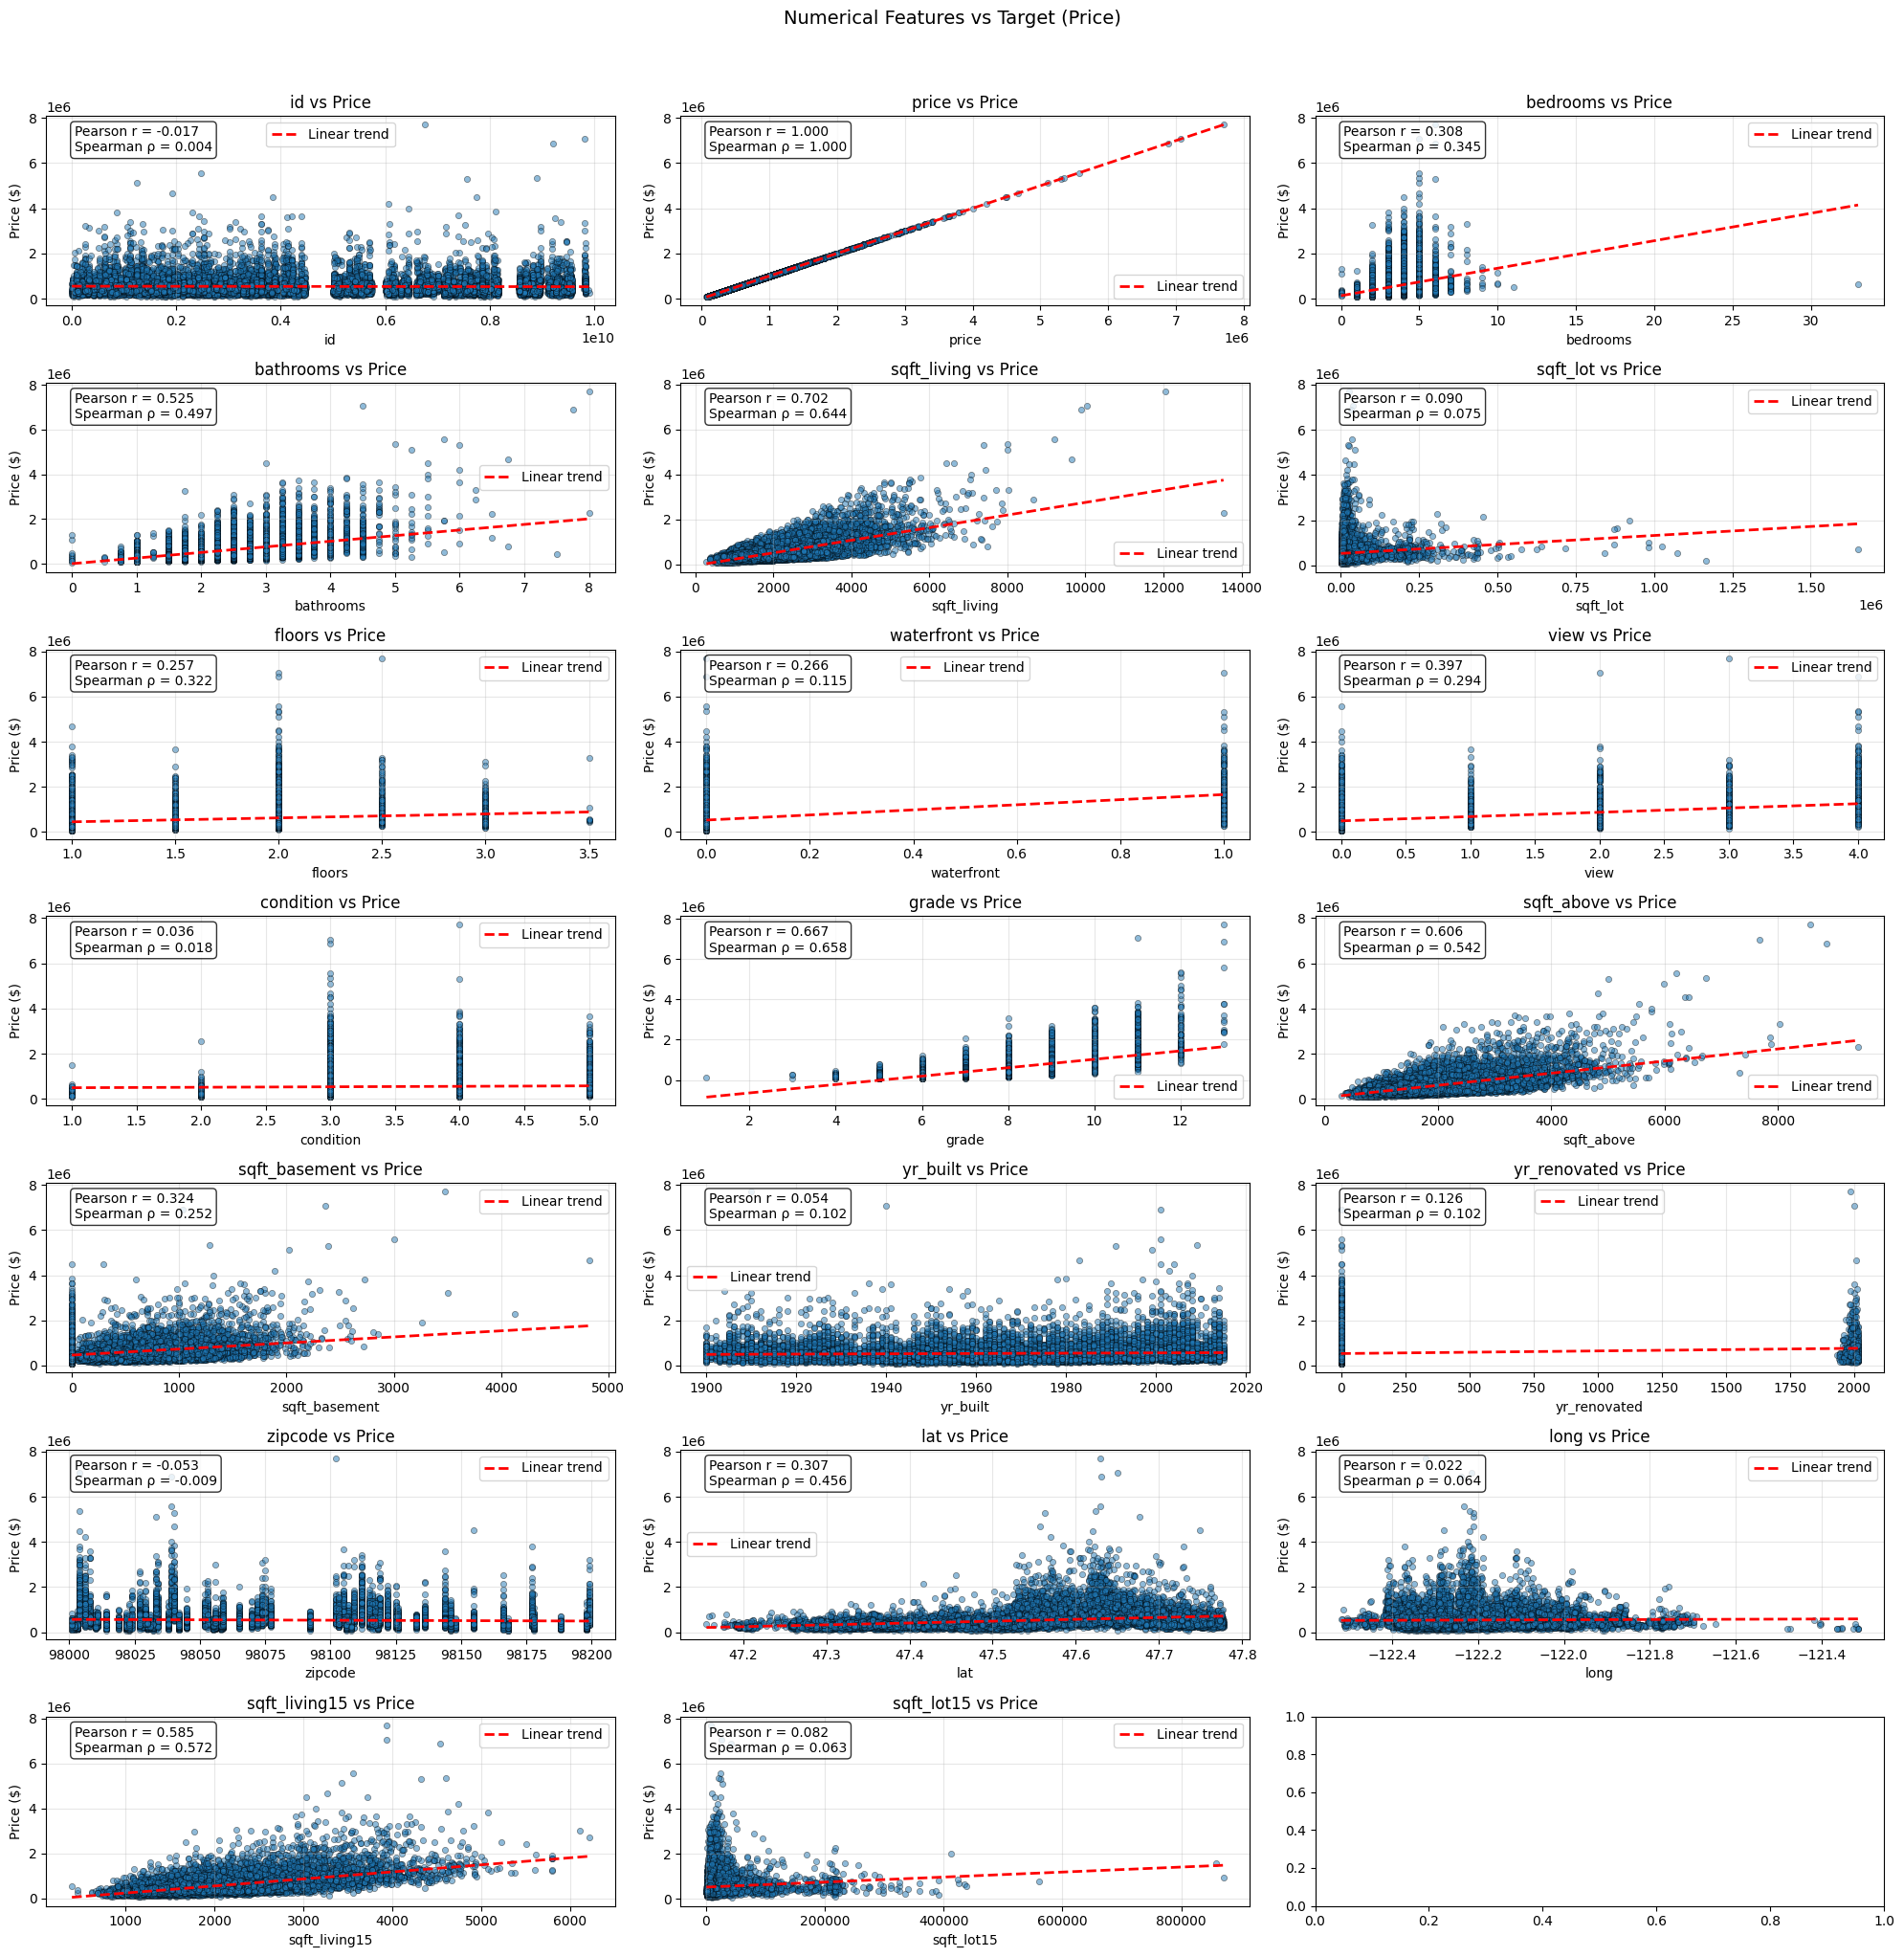

In [ ]:

#those plts help to understand the relationship between the features(and thier correlations) and the target variable :the effect of the variation of each feature on the target
# Select top numerical features for detailed analysis
top_numerical = numerical_cols[:]  # First 6 numerical features

fig, axes = plt.subplots(7, 3, figsize=(20, 20))
axes = axes.flatten()

for idx, feature in enumerate(top_numerical):
    ax = axes[idx]
    
    # Scatter plot with regression line
    scatter = ax.scatter(df[feature], df['price'], alpha=0.5, s=20, edgecolor='black', linewidth=0.5)
    
    # Add regression line
    z = np.polyfit(df[feature], df['price'], 1)
    p = np.poly1d(z)
    ax.plot(np.sort(df[feature]), p(np.sort(df[feature])), "r--", linewidth=2, label='Linear trend')
    
    # Calculate correlation
    pearson_corr = df[feature].corr(df['price'])
    spearman_corr = df[feature].corr(df['price'], method='spearman')
    
    # Add correlation info
    ax.text(0.05, 0.95, f'Pearson r = {pearson_corr:.3f}\nSpearman ρ = {spearman_corr:.3f}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    
    ax.set_xlabel(feature)
    ax.set_ylabel('Price ($)')
    ax.set_title(f'{feature} vs Price')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Numerical Features vs Target (Price)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()




📊 Analysis of Categorical Variable: date
--------------------------------------------------
   Unique values: 372

   Value distribution:
      20140623T000000: 142 (0.7%)
      20140626T000000: 131 (0.6%)
      20140625T000000: 131 (0.6%)
      20140708T000000: 127 (0.6%)
      20150427T000000: 126 (0.6%)
      20150325T000000: 123 (0.6%)
      20150422T000000: 121 (0.6%)
      20140709T000000: 121 (0.6%)
      20150428T000000: 121 (0.6%)
      20150414T000000: 121 (0.6%)


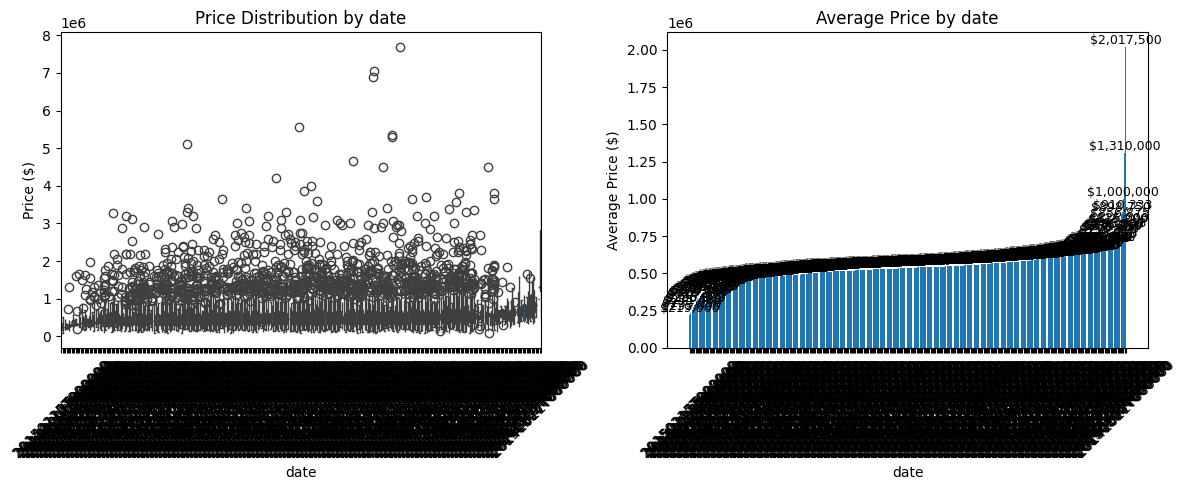


   Statistical Analysis:
   ANOVA F-statistic: 1.162
   P-value: 0.017811
   ✅ Statistically significant difference in means across categories
   Effect size (η²): 0.020
   Interpretation: Small effect



In [ ]:
#to understand the relationship between the feature and the target variable ,we use the Anova test
#the anova test is used to test the null hypothesis that the means of two or more groups are equal
#we use it for categorical variables to verify if there is a relationship between the feature and the target variable

categorical_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()

if categorical_vars:
    for cat_var in categorical_vars:
        print(f"\n📊 Analysis of Categorical Variable: {cat_var}")
        print("-" * 50)
        
        # Basic info
        unique_count = df[cat_var].nunique()
        print(f"   Unique values: {unique_count}")
        
        # Show value counts
        value_counts = df[cat_var].value_counts()
        print(f"\n   Value distribution:")
        for value, count in value_counts.head(10).items():
            percentage = (count / len(df)) * 100
            print(f"      {value}: {count} ({percentage:.1f}%)")
        
        # Relationship with target
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Box plot
        order = df.groupby(cat_var)['price'].median().sort_values().index
        sns.boxplot(x=cat_var, y='price', data=df, ax=axes[0], order=order)
        axes[0].set_xlabel(cat_var)
        axes[0].set_ylabel('Price ($)')
        axes[0].set_title(f'Price Distribution by {cat_var}')
        axes[0].tick_params(axis='x', rotation=45)
        
        # Bar plot with mean price
        mean_prices = df.groupby(cat_var)['price'].mean().sort_values()
        bars = axes[1].bar(range(len(mean_prices)), mean_prices.values)
        axes[1].set_xlabel(cat_var)
        axes[1].set_ylabel('Average Price ($)')
        axes[1].set_title(f'Average Price by {cat_var}')
        axes[1].set_xticks(range(len(mean_prices)))
        axes[1].set_xticklabels(mean_prices.index, rotation=45)
        
        # Add value labels on bars
        for bar, price in zip(bars, mean_prices.values):
            height = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2., height,
                        f'${price:,.0f}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        # Statistical test for categorical relationship
        print(f"\n   Statistical Analysis:")
        
        # ANOVA test for difference in means
        groups = [df[df[cat_var] == val]['price'].values for val in df[cat_var].unique()]
        
        if len(groups) > 1:
            from scipy.stats import f_oneway
            f_stat, p_value = f_oneway(*groups)
            print(f"   ANOVA F-statistic: {f_stat:.3f}")
            print(f"   P-value: {p_value:.6f}")
            
            if p_value < 0.05:
                print("   ✅ Statistically significant difference in means across categories")
            else:
                print("   ⚠️  No statistically significant difference in means")
        
        # Calculate effect size (eta squared)
        if len(groups) > 1:
            # Between-group sum of squares
            grand_mean = df['price'].mean()
            ss_between = sum([len(g) * (g.mean() - grand_mean)**2 for g in groups])
            ss_total = sum((df['price'] - grand_mean)**2)
            eta_squared = ss_between / ss_total
            
            print(f"   Effect size (η²): {eta_squared:.3f}")
            print(f"   Interpretation: {'Large' if eta_squared > 0.14 else 'Medium' if eta_squared > 0.06 else 'Small'} effect")
        
        print()
else:
    print("No categorical variables in the dataset")

# Data Cleaning

In [ ]:
print("Missing values cause problems in TWO main areas:")
print("="*70)

print("\n🔴 A. PROBLEMS IN DATA ANALYSIS:")
print("-"*40)
print("""
1. Statistical Bias
   • Mean, median calculations become inaccurate
   • Standard deviation is underestimated
   • Correlation coefficients are biased

2. Visualization Issues
   • Missing bars in bar charts
   • Gaps in line plots
   • Distorted distributions in histograms

3. Sampling Bias
   • If missingness is NOT random (MNAR), analysis results are biased
   • Certain groups may be underrepresented

4. Reduced Statistical Power
   • Smaller effective sample size
   • Less precise estimates
   • Wider confidence intervals
""")

print("\n🔴 B. PROBLEMS IN MACHINE LEARNING MODELS:")
print("-"*40)
print("""
1. Model Training FAILS with most algorithms:
   • Linear/Logistic Regression - CANNOT handle NaN
   • Support Vector Machines (SVM) - CANNOT handle NaN
   • Neural Networks - CANNOT handle NaN
   • k-Nearest Neighbors - CANNOT handle NaN (unless imputed)
   • Decision Trees - Can handle, but splits become suboptimal

2. Model Performance Degradation:
   • Reduced accuracy
   • Poor generalization
   • Unstable predictions

3. Technical Errors:
   • sklearn: "Input contains NaN" error
   • TensorFlow/PyTorch: NaN gradients, training crashes
   • XGBoost/LightGBM: May handle but with warnings

4. Feature Importance Distortion:
   • Missing patterns can be informative but handled incorrectly
   • Algorithms may over/under-weight features with missingness
""")
# we can use imputation to handle missing values
# imputation is the process of replacing missing values with estimated values
# there are many ways to impute missing values
# 1. mean imputation
# 2. median imputation
# 3. mode imputation
# 4. random imputation
# 5. k-NN imputation
# for numeric variable
for col in df.columns:
    if df[col].dtype == "int64" or df[col].dtype == "float64":
        df[col].fillna(df[col].mean(), inplace=True)
# #for categorical variable
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
#for datetime variable
for col in df.columns:
    if df[col].dtype == "datetime64[ns]":
        df[col].fillna(df[col].mean(), inplace=True)
#or we can simply drop nan values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df.dropna(subset=[col], inplace=True)



In [ ]:
print("🚨 DUPLICATE VALUES: MAJOR PROBLEMS THEY CAUSE")
print("="*80)

print("\n🔴 A. PROBLEMS IN DATA ANALYSIS:")
print("-"*50)
print("""
1. **Statistical Bias**:
   • Inflated sample size → false confidence
   • Skewed distributions → wrong conclusions
   • Biased mean/variance → incorrect inferences

2. **Misleading Visualizations**:
   • Over-represented categories in bar charts
   • Dense clusters in scatter plots hiding true patterns
   • Distorted histograms showing false peaks

3. **Correlation Inflation**:
   • Artificial correlation between variables
   • Spurious relationships appear significant
   • Multicollinearity issues

4. **Time Series Problems**:
   • Duplicate timestamps → sequence errors
   • Incorrect trend analysis
   • Autocorrelation distortion
""")

print("\n🔴 B. PROBLEMS IN MACHINE LEARNING:")
print("-"*50)
print("""
1. **Model Overfitting**:
   • Models memorize duplicates instead of learning patterns
   • Overly optimistic training performance
   • Poor generalization to new data

2. **Training/Test Contamination**:
   • Same data in both sets → data leakage
   • Artificially high test accuracy
   • False sense of model quality

3. **Biased Feature Importance**:
   • Features correlated with duplicates get inflated importance
   • Real important features may be overlooked
   • Incorrect feature selection

4. **Algorithm-Specific Issues**:
   • K-Nearest Neighbors: Duplicates dominate neighbors
   • Decision Trees: Prefer splits that separate duplicates
   • Neural Networks: Waste epochs on same patterns
   • SVM: Support vectors dominated by duplicates
""")

print("\n🔴 C. BUSINESS & DECISION-MAKING PROBLEMS:")
print("-"*50)
print("""
1. **Financial Errors**:
   • Double-counting transactions
   • Incorrect revenue calculations
   • Wrong inventory counts

2. **Customer Analysis Issues**:
   • Duplicate customer records
   • Inaccurate CLV (Customer Lifetime Value)
   • Wrong segmentation

3. **Operational Problems**:
   • Resource allocation based on wrong data
   • Inefficient processes
   • Compliance violations
""")
df = df.drop_duplicates()

In [ ]:
# FIX DATA TYPES
# 1. Convert columns to appropriate data types
# for datetimes ,for mix vlaues..
# for numeric columns with object dtype
for col in df.columns:
    if df[col].dtype == 'object':
        converted = pd.to_numeric(df[col], errors='coerce')
        if converted.notna().sum() > len(df) * 0.8:  # If 80%+ success
            df[col] = converted
            new_dtype = 'float64'
# for dATE TIME
for col in df.columns:
    converted = pd.to_datetime(df[col], errors='coerce')
    if converted.notna().sum() > len(df) * 0.5:  # If 50%+ success
        df[col] = converted
        new_dtype = 'datetime64[ns]'



In [ ]:
# clean text data
text_columns = df.select_dtypes(include=['object']).columns
for col in text_columns:
    # Store original for comparison
    original = df[col].copy()
            
    # Basic text cleaning
    df[col] = df[col].astype(str).apply(lambda x: x.strip() if isinstance(x, str) else x)
            
    # Remove extra whitespace
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)
            

In [ ]:
#Extract numeric values from text 
text = re.sub(r'[$,€£¥]', '', text)
text = text.replace(',', '')
        
# Handle K and M suffixes
if 'K' in text.upper() or 'k' in text:
    text = text.upper().replace('K', '')
    try:
        float(text) * 1000
    except:
        np.nan
elif 'M' in text.upper():
    text = text.upper().replace('M', '')
    try:
        float(text) * 1000000
    except:
        np.nan
        
        # Extract numbers
    numbers = re.findall(r'[-+]?\d*\.\d+|\d+', text)
    if numbers:
        float(numbers[0])

In [ ]:
#HANDLE OUTLIERS
#outliers may cause problems in our models 
#we can remove them or replace them with the mean or median
numeric_cols =df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    # we can use caping to replace the outliers with the upper and lower bounds(caping means replacing the outliers with the upper and lower bounds)
    df[col] = df[col].clip(lower_bound, upper_bound)
    # we can Remove rows with outliers
    df = df[~df.index.isin(outliers.index)]
    #we can Apply log transformation
    df[col] = np.log1p(df[col])



In [ ]:
# ENCODING
# we apply encoding to categorical variables
# we use LabelEncoder for ordinal variables
# we use OneHotEncoder for multi-class variables

In [ ]:
print("\n📊 Why Encoding is NECESSARY:")
print("-"*40)
print("""
Most ML algorithms work with NUMERICAL data only:
• Linear/Logistic Regression → Needs numbers
• Neural Networks → Needs numbers  
• Support Vector Machines → Needs numbers
• k-Nearest Neighbors → Needs numbers

Exceptions (can handle categorical directly):
• Decision Trees / Random Forests
• CatBoost (specialized for categorical)
• Some implementations of XGBoost/LightGBM
""")

print("\n🎯 Two Main Types of Encoding:")
print("-"*40)
print("""
1. LABEL ENCODING (Ordinal Encoding)
   • Converts categories → Integers (0, 1, 2, ...)
   • Preserves ORDER if categories have natural order
   • Example: ["Low", "Medium", "High"] → [0, 1, 2]

2. ONE-HOT ENCODING (Dummy Encoding)
   • Creates NEW binary columns for each category
   • No ordinal relationship assumed
   • Example: ["Red", "Blue", "Green"] → 
               Red_1 Blue_1 Green_1
                 1      0      0
                 0      1      0  
                 0      0      1
""")

In [ ]:
# Determine ordinal vs nominal
ordinal_cols = []
nominal_cols = []

for col in categorical_cols:
    unique_vals = df[col].unique()
    
    # Check if it looks ordinal
    is_ordinal = False
    if len(unique_vals) < 10:
        is_ordinal = True
    else:
        is_ordinal = False
    
    if is_ordinal:
        ordinal_cols.append(col)
    else:
        nominal_cols.append(col)


In [ ]:
print("1️⃣ LABEL ENCODING (for ORDINAL Variables)")
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ordinal_cols:
    
    df[f'{col}_sklearn'] = le.fit_transform(df[col])


In [ ]:
print("2️⃣ ONE-HOT ENCODING (for NOMINAL Variables)")
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop='first') 
ohe_array = ohe.fit_transform(df[nominal_cols])


In [ ]:
#STANDARDIZE & NORMALIZE
print("\n🎯 WHY WE NEED SCALING:")
print("-"*50)
print("""
Most ML algorithms are SENSITIVE to feature scales:

1. **Distance-based algorithms**:
   • k-Nearest Neighbors (k-NN) → Uses Euclidean distance
   • Support Vector Machines (SVM) → Uses distance to hyperplane
   • k-Means Clustering → Uses distance between points
   • Neural Networks → Gradient descent optimization

2. **Gradient-based algorithms**:
   • Linear/Logistic Regression → Gradient descent
   • Neural Networks → Backpropagation
   • Regularized models (Lasso, Ridge)

3. **Regularization penalties**:
   • L1/L2 regularization assume features are comparable
   • Unscaled features → Unequal regularization

4. **Convergence speed**:
   • Gradient descent converges faster with scaled features
   • Prevents numerical instability
""")

print("\n🔍 PROBLEMS WITHOUT SCALING:")
print("-"*50)
print("""
Example: House Price Prediction
• Feature 1: Number of rooms (2-5)
• Feature 2: Square footage (1000-5000)
• Feature 3: Distance to city (1-20 km)

Without scaling:
• Square footage dominates distance calculations
• Algorithms think sqft is 1000x more important
• Wrong feature importance
• Slow convergence
• Poor model performance
""")

In [ ]:
from pandas import numerical_data


print("1️⃣ STANDARDIZATION (Z-score Normalization)")
print("="*80)

print("\n📌 FORMULA: Standardization")
print("-" * 40)
print("""
            x - μ
    z = ------------
             σ
    
Where:
    • x = original value
    • μ = mean of the feature
    • σ = standard deviation of the feature
    • z = standardized value (z-score)

Result:
    • Mean = 0
    • Standard Deviation = 1
    • Preserves original distribution shape
    • Handles outliers poorly (they get extreme z-scores)
""")

print("\n🎯 WHEN TO USE STANDARDIZATION:")
print("-" * 40)
print("""
✅ USE STANDARDIZATION WHEN:
1. Features follow NORMAL/Gaussian distribution
2. Algorithm assumes normality:
   • Linear/Logistic Regression
   • Linear Discriminant Analysis (LDA)
   • Principal Component Analysis (PCA)
3. Distance-based algorithms:
   • k-Nearest Neighbors (k-NN)
   • k-Means Clustering
   • Support Vector Machines (SVM)
4. Neural Networks (often)
5. Features have outliers but you want to keep them

❌ AVOID STANDARDIZATION WHEN:
1. Data has MANY outliers
2. Features don't follow normal distribution
3. Using tree-based models (they don't need scaling)
4. Binary features (0/1)
""")
scaler = StandardScaler()

# Fit and transform
scaled_array = scaler.fit_transform(df[numerical_data])
df_standardized = pd.DataFrame(scaled_array, columns=[f'{col}_std' for col in numerical_data])

In [ ]:
print("2️⃣ NORMALIZATION (Min-Max Scaling)")
print("="*80)

print("\n📌 FORMULA: Normalization (Min-Max Scaling)")
print("-" * 40)
print("""
        x - min(x)
    x' = ------------
        max(x) - min(x)

Where:
    • x = original value
    • min(x) = minimum value in feature
    • max(x) = maximum value in feature
    • x' = normalized value (0 to 1)

Result:
    • All values scaled to [0, 1] range
    • Mean and variance depend on data
    • Sensitive to outliers (min/max affected)
    • Preserves relationships
""")

print("\n🎯 WHEN TO USE NORMALIZATION:")
print("-" * 40)
print("""
✅ USE NORMALIZATION WHEN:
1. Bounded range needed [0, 1]
2. Neural Networks (sigmoid/tanh activation functions)
3. Image processing (pixel values 0-255 → 0-1)
4. Gradient descent optimization
5. k-Nearest Neighbors (distance calculations)
6. When you know theoretical min/max bounds

❌ AVOID NORMALIZATION WHEN:
1. Data has OUTLIERS (they squeeze normal values)
2. Features have different value ranges but comparable scales
3. Using algorithms sensitive to variance (PCA)
4. Features already on similar scale
""")

# Apply Normalization
print("\n🔧 Applying MinMaxScaler:")
print("-" * 50)

# Create scaler
minmax_scaler = MinMaxScaler()

# Fit and transform
normalized_array = minmax_scaler.fit_transform(df[numerical_data])
df_normalized = pd.DataFrame(normalized_array, columns=[f'{col}_norm' for col in numerical_data])